In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to the database you created
conn = sqlite3.connect('retail_db.sqlite')

# 2. Run a SQL Query to get the data
# We are selecting everything, but in a real job, you might only select specific columns
df = pd.read_sql("SELECT * FROM transactions", conn)

# 3. Close the connection (Good practice!)
conn.close()

# 4. Preview the raw data
print(f"Total rows loaded: {len(df)}")
df.head()

Total rows loaded: 525461


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
# --- DATA CLEANING & PREPROCESSING ---

# 1. Handle Missing Values
# Logic: We cannot do Customer Segmentation (RFM) if we don't know who the customer is.
# We will drop rows where Customer ID is null for the analysis, but keep them for general sales trends if needed.
print(f"Missing Customer IDs before: {df['Customer ID'].isnull().sum()}")
df_clean = df.dropna(subset=['Customer ID']).copy()

# 2. Fix Data Types
# 'InvoiceDate' is currently a string (object). We need it as a DateTime object for time-series analysis.
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 3. Feature Engineering: Create a 'TotalSales' column
# The dataset has Quantity and Price, but not the total value of the line item.
df_clean['TotalSales'] = df_clean['Quantity'] * df_clean['Price']

# 4. Remove "Returns" and "Errors" for the Sales Analysis
# Negative Quantity usually means a return or cancellation.
# We will separate these into two dataframes: one for Sales, one for Returns.
df_returns = df_clean[df_clean['Quantity'] < 0]
df_sales = df_clean[df_clean['Quantity'] > 0]

print(f"Cleaned Sales Rows: {len(df_sales)}")
print(f"Returns Found: {len(df_returns)}")

Missing Customer IDs before: 107927
Cleaned Sales Rows: 407695
Returns Found: 9839


In [3]:
# Check descriptive statistics to find outliers (e.g., someone bought 10,000 units?)
print("--- Statistical Summary of Sales ---")
print(df_sales[['Quantity', 'Price', 'TotalSales']].describe())

--- Statistical Summary of Sales ---
            Quantity          Price     TotalSales
count  407695.000000  407695.000000  407695.000000
mean       13.586686       3.294188      21.663261
std        96.842229      34.756655      77.147356
min         1.000000       0.000000       0.000000
25%         2.000000       1.250000       4.950000
50%         5.000000       1.950000      11.900000
75%        12.000000       3.750000      19.500000
max     19152.000000   10953.500000   15818.400000


C:\Users\niakh\AppData\Local\Temp\ipykernel_14264\1554748660.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df_sales.set_index('InvoiceDate').resample('M')['TotalSales'].sum()


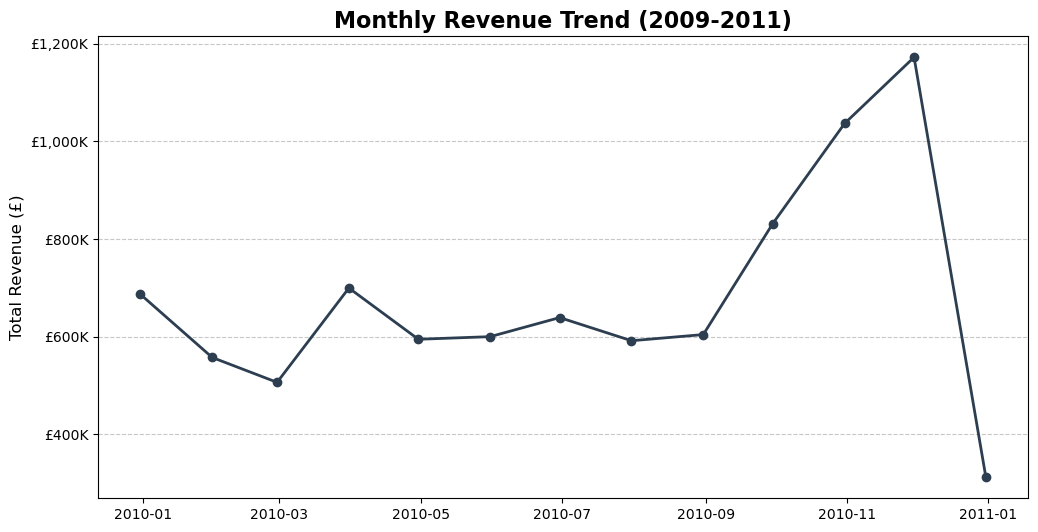

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Resample data by Month ('M') and sum the TotalSales
# Note: We use the 'df_sales' dataframe we created in the cleaning step
monthly_sales = df_sales.set_index('InvoiceDate').resample('M')['TotalSales'].sum()

# 2. Plotting
plt.figure(figsize=(12, 6))
# Plot line with markers
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', color='#2c3e50', linewidth=2)

# 3. Styling for Professionalism
plt.title('Monthly Revenue Trend (2009-2011)', fontsize=16, fontweight='bold')
plt.ylabel('Total Revenue (£)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Format y-axis to show money (e.g., 100000 -> 100K)
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '£{:,.0f}'.format(x/1000) + 'K'))

plt.show()

C:\Users\niakh\AppData\Local\Temp\ipykernel_14264\1795379443.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


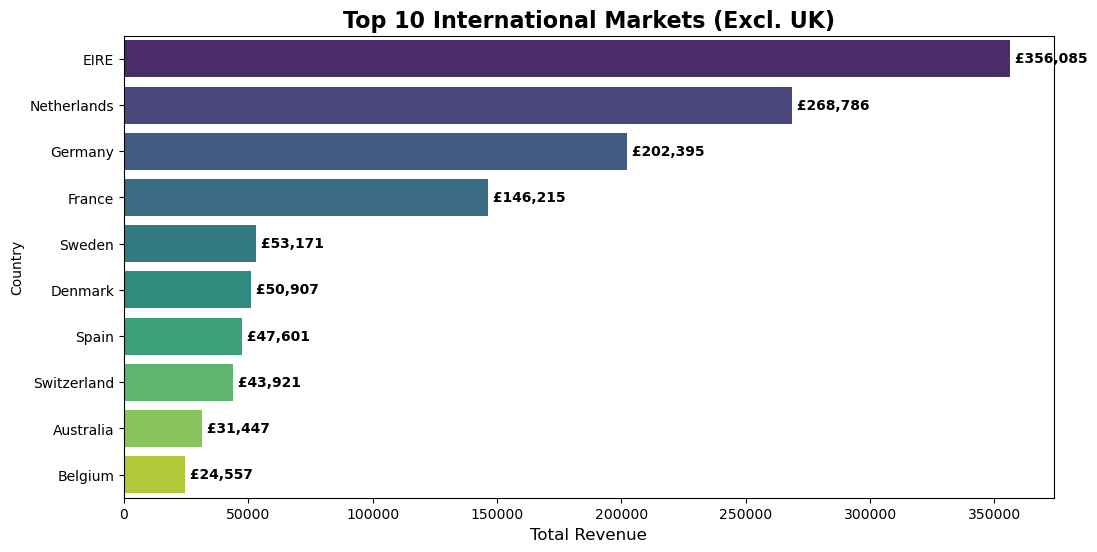

In [5]:
# 1. Aggregate Sales by Country (excluding UK to see the others better)
country_sales = df_sales[df_sales['Country'] != 'United Kingdom'].groupby('Country')['TotalSales'].sum()
top_countries = country_sales.sort_values(ascending=False).head(10)

# 2. Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')

# 3. Styling
plt.title('Top 10 International Markets (Excl. UK)', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue', fontsize=12)

# Add data labels to the end of bars
for index, value in enumerate(top_countries.values):
    plt.text(value, index, f' £{value:,.0f}', va='center', fontweight='bold')

plt.show()

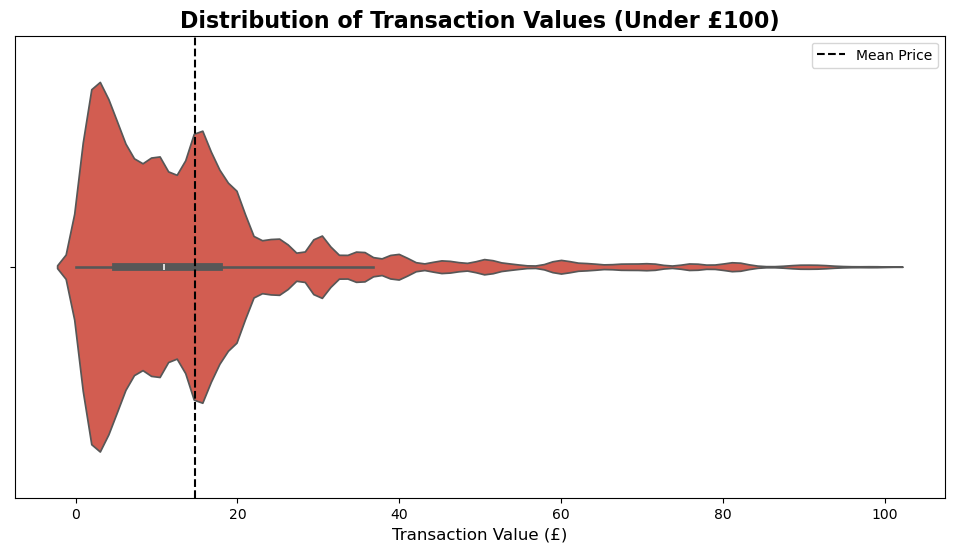

In [6]:
# Filter out extreme outliers for a cleaner view (Transactions under £100)
filtered_sales = df_sales[df_sales['TotalSales'] < 100]

plt.figure(figsize=(12, 6))

# A Violin plot shows the density of data (fat parts = common values)
sns.violinplot(x=filtered_sales['TotalSales'], color='#e74c3c')

plt.title('Distribution of Transaction Values (Under £100)', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Value (£)', fontsize=12)
plt.axvline(filtered_sales['TotalSales'].mean(), color='black', linestyle='--', label='Mean Price')
plt.legend()

plt.show()

In [ ]:
building a customer segmentation engine.

In [7]:
import pandas as pd
import datetime as dt

# 1. Set a "Reference Date" (The day we pretend we are analyzing the data)
# We use the last day in the dataset + 1 day
latest_date = df_sales['InvoiceDate'].max() + dt.timedelta(days=1)

# 2. Group by Customer and Calculate Metrics
rfm = df_sales.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days, # Recency: Days since last order
    'Invoice': 'nunique',                                  # Frequency: Count of unique orders
    'TotalSales': 'sum'                                    # Monetary: Total money spent
})

# 3. Rename columns for clarity
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalSales': 'Monetary'
}, inplace=True)

# 4. Show the top 5 customers
print(rfm.head())

             Recency  Frequency  Monetary
Customer ID                              
12346.0          165         11    372.86
12347.0            3          2   1323.32
12348.0           74          1    222.16
12349.0           43          3   2671.14
12351.0           11          1    300.93


In [8]:
# 1. Create Labels (4 = Best, 1 = Worst for Recency)
# Note: Low Recency is good (bought yesterday), so we swap the labels
r_labels = range(4, 0, -1) 
f_labels = range(1, 5)
m_labels = range(1, 5)

# 2. Divide data into 4 equal groups (Quartiles)
r_groups = pd.qcut(rfm['Recency'], q=4, labels=r_labels)
f_groups = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=f_labels) # .rank() handles ties
m_groups = pd.qcut(rfm['Monetary'], q=4, labels=m_labels)

# 3. Create new columns with the scores
rfm['R'] = r_groups.values
rfm['F'] = f_groups.values
rfm['M'] = m_groups.values

# 4. Concatenate to get a "RFM Score" (e.g., "444" is a perfect customer)
rfm['RFM_Score'] = rfm.apply(lambda x: str(x['R']) + str(x['F']) + str(x['M']), axis=1)

# 5. Define "Champions" vs "Hibernating"
def segment_customer(score):
    if score == '444':
        return 'Champion'
    elif score[0] == '1': # Low Recency score (meaning high days since purchase)
        return 'Hibernating'
    elif score[1] == '4': # High Frequency
        return 'Loyal Customer'
    else:
        return 'Other'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

print(rfm['Segment'].value_counts())

Segment
Other          3236
Hibernating    1078
Name: count, dtype: int64


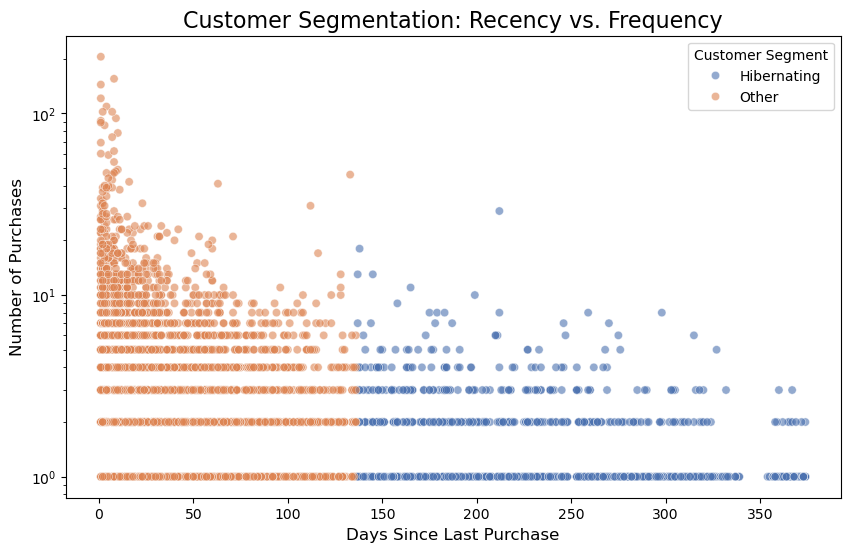

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Scatter plot: Recency vs Frequency, colored by Segment
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Segment', palette='deep', alpha=0.6)

plt.title('Customer Segmentation: Recency vs. Frequency', fontsize=16)
plt.xlabel('Days Since Last Purchase', fontsize=12)
plt.ylabel('Number of Purchases', fontsize=12)
plt.legend(title='Customer Segment')

# Log scale helps visualize the data better because some people buy HUGE amounts
plt.yscale('log') 

plt.show()